# FIFA World Cup 2026 - Objective 1 midfield analysis

> Among midfielders who played at least 180 minutes, did players from knockout-stage teams win more tackles per 90 than players whose teams exited in the group stage?

The notebook covers question formulation, wrangling, sampling, descriptive statistics, confidence intervals and a Welch two-sample t-test.

## 1. Design

Raw tackle totals favour teams that played more matches, so the outcome is tackles won divided by 90s played. Eligible players have `MF` in their position and at least 2.0 90s.

**H0:** mean knockout rate - mean exit rate = 0.  
**H1:** mean knockout rate - mean exit rate is not 0.  
**Decision level:** two-sided alpha = 0.05.

Numeric data: [FBref 2026 World Cup miscellaneous statistics](https://fbref.com/en/comps/1/misc/World-Cup-Stats). Competition reference: [FIFA](https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics).

In [1]:
from pathlib import Path
import importlib
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import src.analyse_midfield as analysis
importlib.reload(analysis)

from src.analyse_midfield import (
    STAGES, build_data_quality_summary, build_descriptive_statistics,
    draw_stratified_sample, load_and_prepare, run_analysis
)

## 2. Wrangling and validation

The workflow standardises numeric fields, verifies stage against squad playing time, derives per-90 variables, checks unique player-team records and rejects missing or ineligible rows.

In [2]:
INPUT = ROOT / 'data/raw/fbref_2026_midfield_population.csv'
summary = run_analysis(ROOT, INPUT, seed=2026, sample_per_stratum=50)
population = load_and_prepare(INPUT)
quality = build_data_quality_summary(population)
display(quality)
assert quality['passed'].all()
print(f"Eligible players: {len(population)} | Teams: {population['team'].nunique()}")

,check,observed,expected,passed
0,eligible_rows,240,240,True
1,unique_player_team_rows,240,240,True
2,missing_primary_outcomes,0,0,True
3,minimum_minutes,180,180,True
4,group_exit_population,60,60,True
5,knockout_population,180,180,True
6,national_teams,48,48,True


Eligible players: 240 | Teams: 48


## 3. Population and sample

The finite population has 60 exit players and 180 knockout players. A stratified random sample selects 50 without replacement from each group using seed 2026. Selection probabilities and inverse weights are stored with every sampled row.

,stage,population_N,sample_n,sampling_fraction,sample_weight
0,Group-stage exit,60,50,0.833,1.2
1,Knockout stage,180,50,0.278,3.6


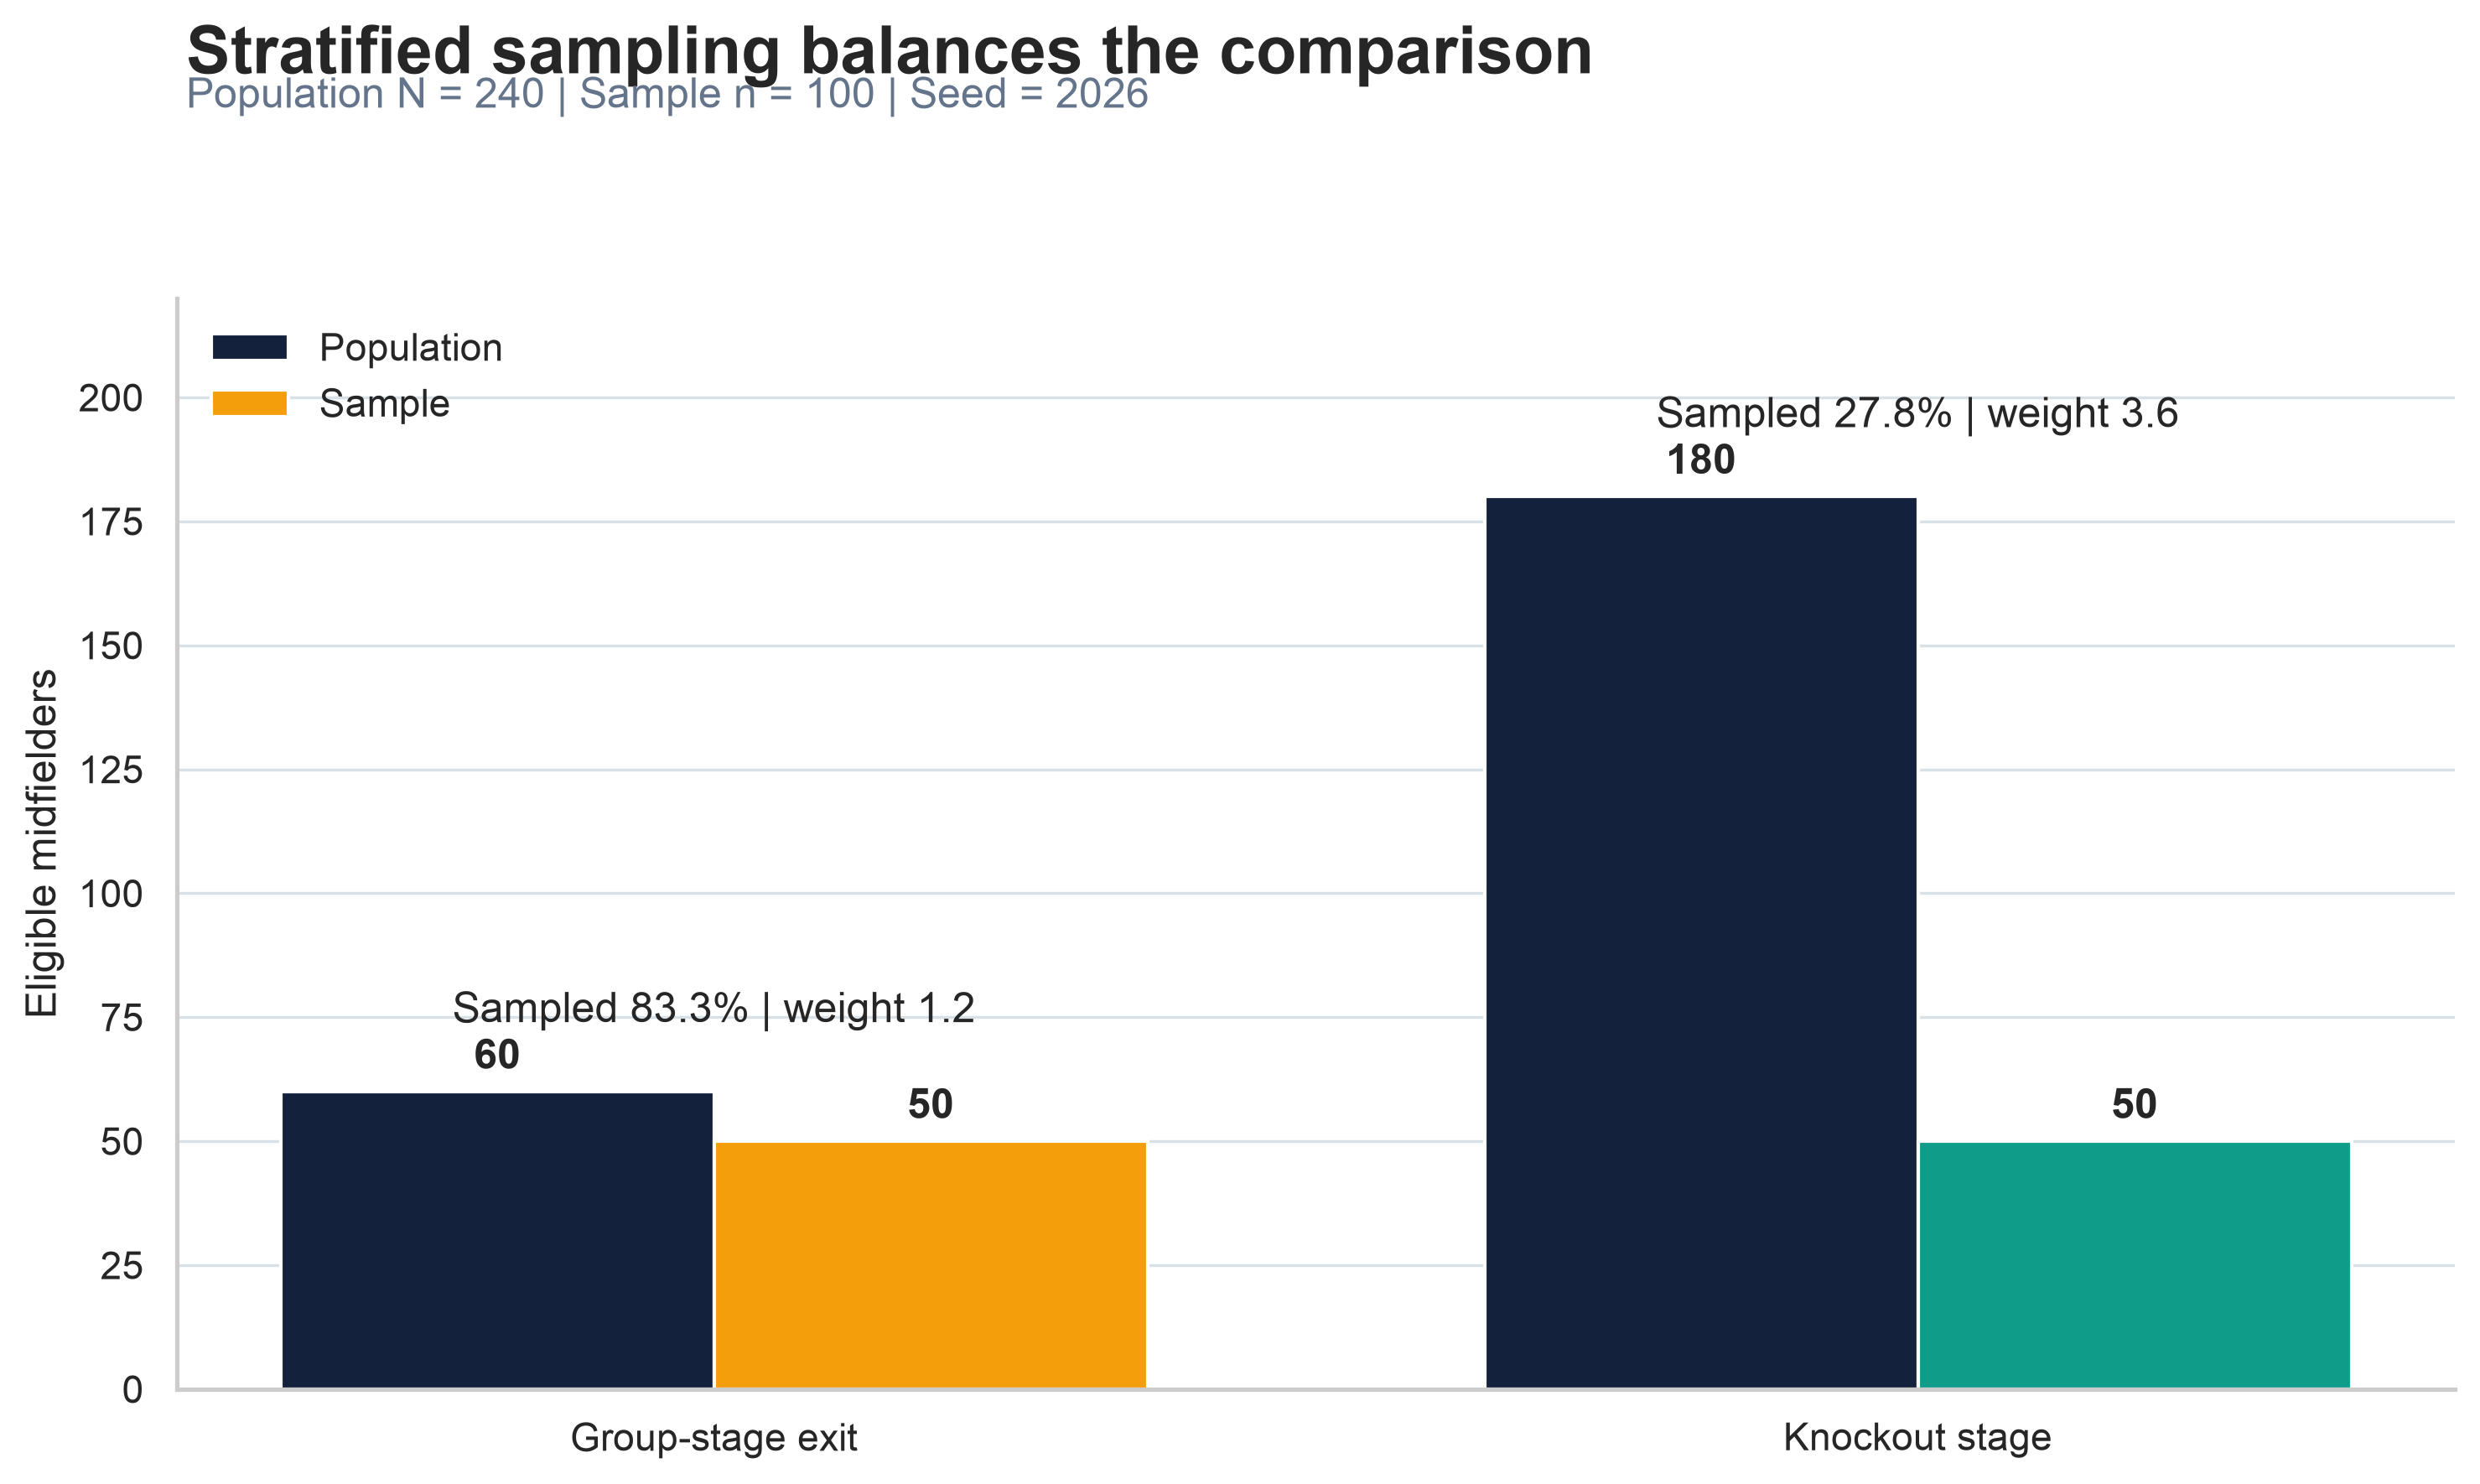

In [3]:
sample = draw_stratified_sample(population, seed=2026, sample_per_stratum=50)
display(pd.read_csv(ROOT / 'data/processed/sample_design.csv').round(3))
display(Image(filename=str(ROOT / 'figures/01_sample_design.png'), width=850))

## 4. Descriptive statistics

Means answer the question; medians, standard deviations, quartiles and ranges describe distribution shape and overlap.

,stage,sample_n,mean,mean_95ci_low,mean_95ci_high,median,standard_deviation,q1,q3,minimum,maximum
0,Group-stage exit,50,0.915,0.710,1.120,0.861,0.721,0.360,1.495,0.0,2.50
1,Knockout stage,50,1.052,0.863,1.241,1.013,0.666,0.514,1.429,0.0,2.75


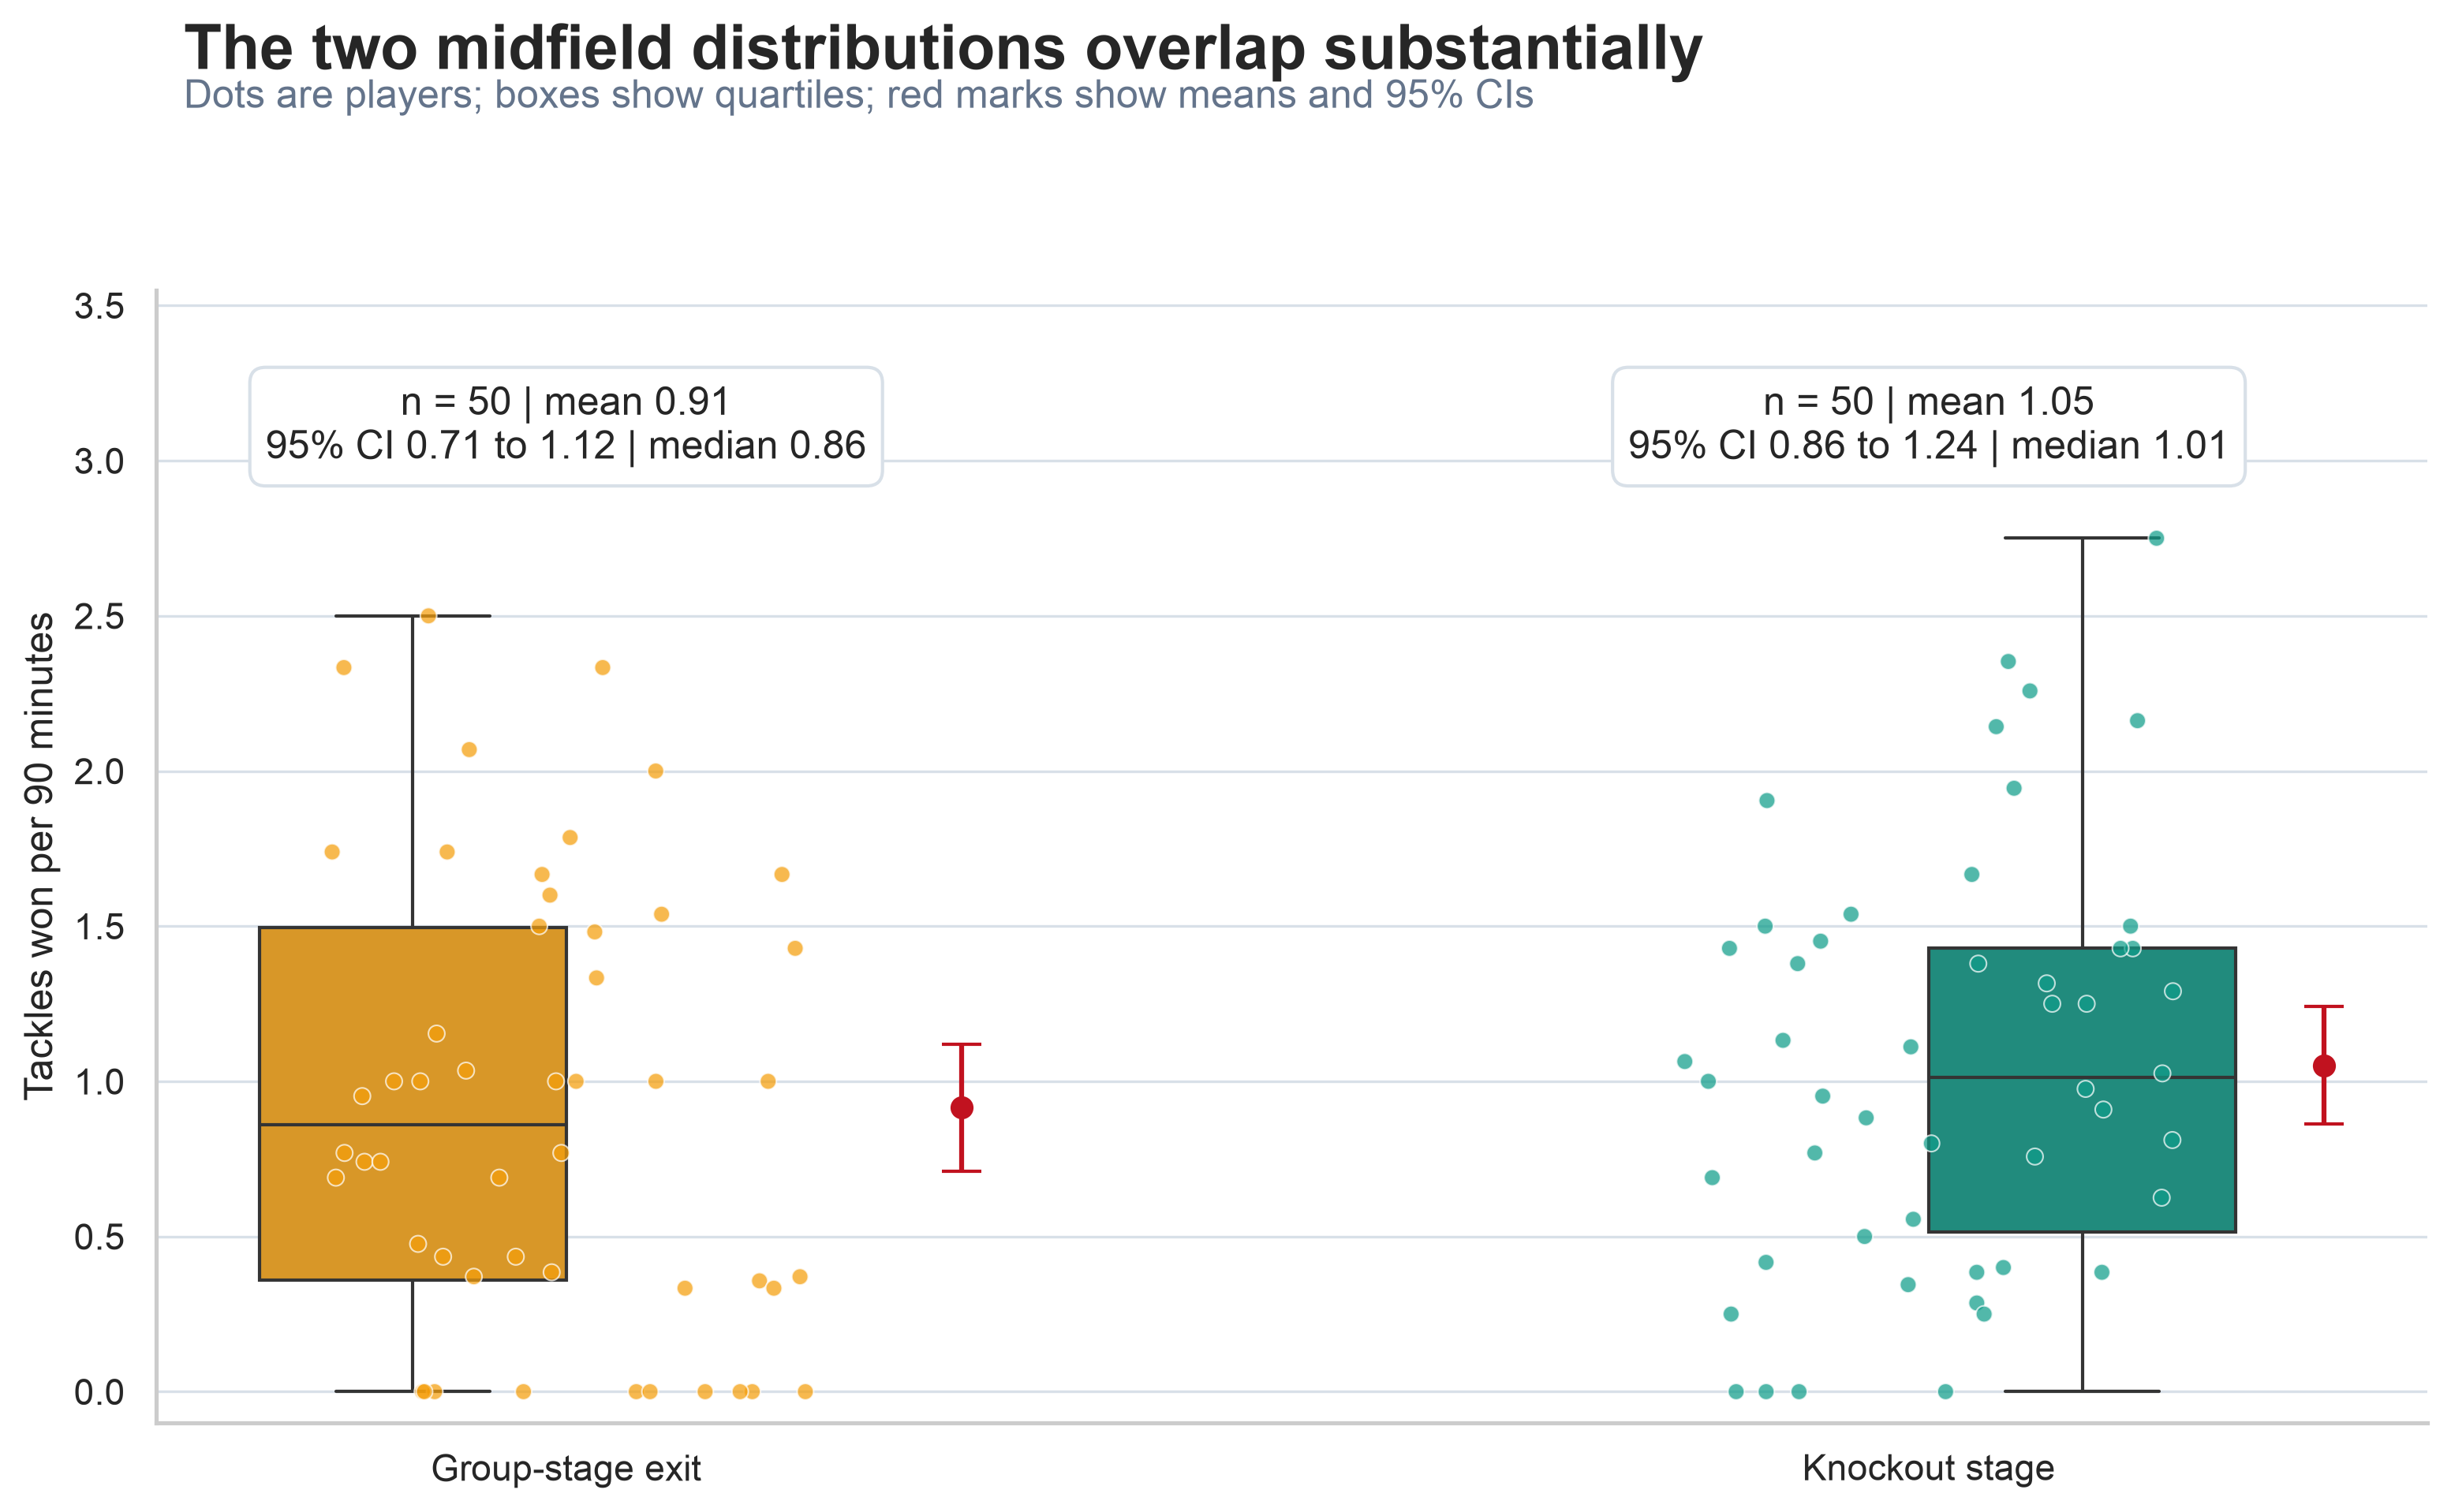

In [4]:
descriptive = build_descriptive_statistics(sample, population)
columns = ['stage', 'sample_n', 'mean', 'mean_95ci_low', 'mean_95ci_high',
           'median', 'standard_deviation', 'q1', 'q3', 'minimum', 'maximum']
display(descriptive[columns].round(3))
display(Image(filename=str(ROOT / 'figures/02_tackles_distribution.png'), width=900))

## 5. Confidence interval and Welch test

Welch's test compares two independent means without requiring equal population variances. The primary parameter is the knockout mean minus the exit mean.

,value
metric,
mean_difference_knockout_minus_exit,0.1370
difference_ci_low,-0.1385
difference_ci_high,0.4125
welch_t,0.9868
welch_df,97.3978
welch_p_two_sided,0.3262
cohens_d,0.1974
hedges_g,0.1959


Difference = +0.137, 95% CI [-0.139, +0.412], Welch t(97.40) = 0.99, p = 0.326


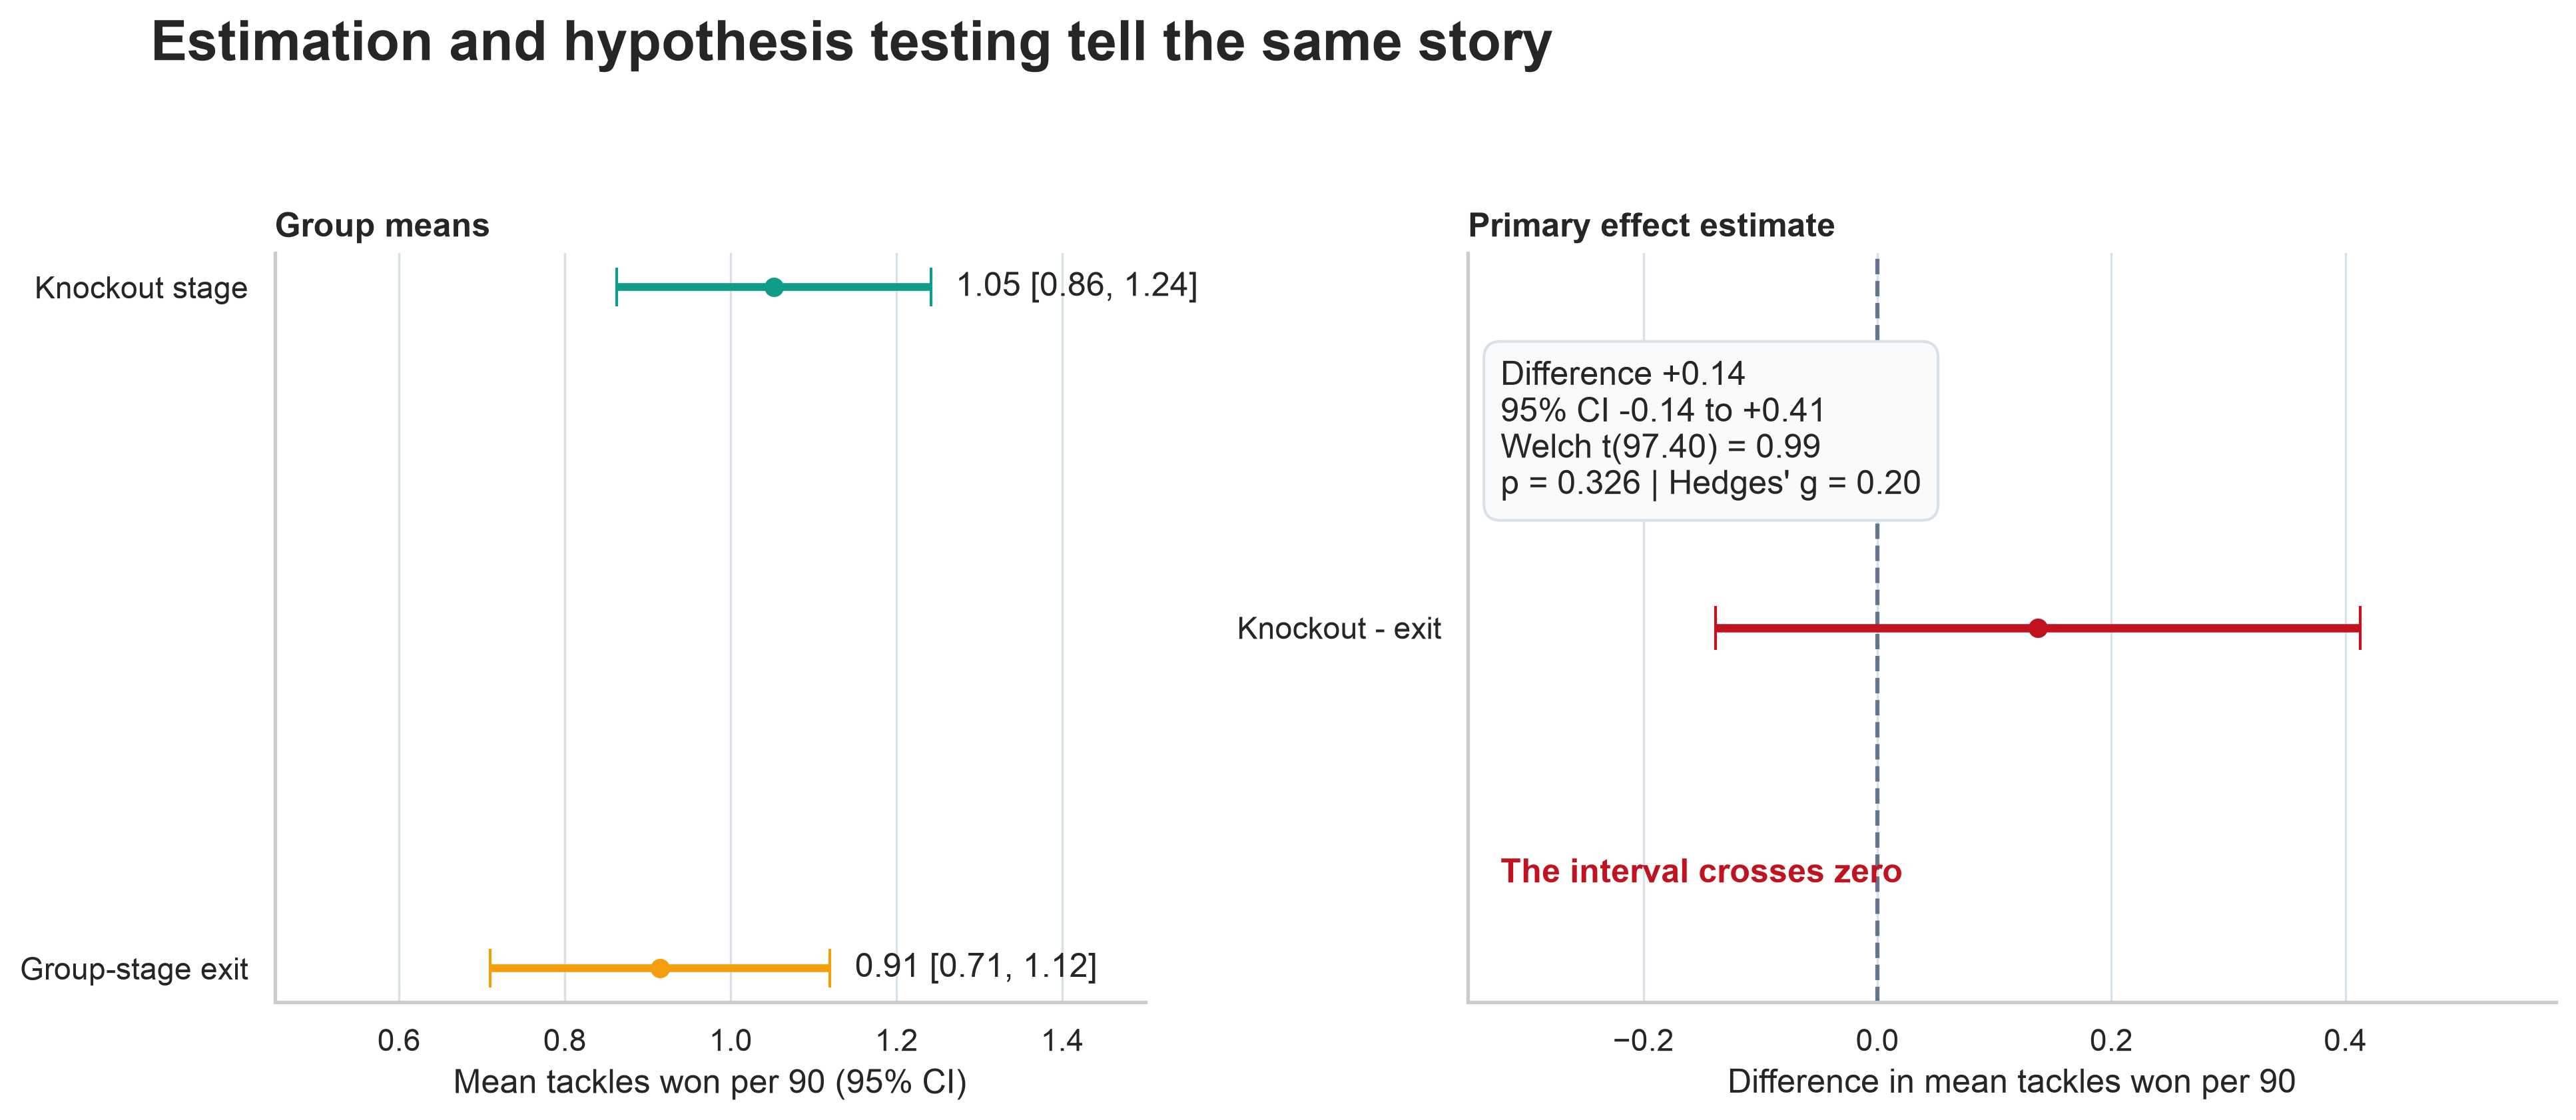

In [5]:
results = pd.read_csv(ROOT / 'data/processed/inferential_results.csv')
wanted = ['mean_difference_knockout_minus_exit', 'difference_ci_low', 'difference_ci_high',
          'welch_t', 'welch_df', 'welch_p_two_sided', 'cohens_d', 'hedges_g']
display(results[results['metric'].isin(wanted)].set_index('metric').round(4))
print(f"Difference = {summary['difference']:+.3f}, 95% CI [{summary['ci_low']:+.3f}, {summary['ci_high']:+.3f}], "
      f"Welch t({summary['degrees_freedom']:.2f}) = {summary['t_statistic']:.2f}, p = {summary['p_value_two_sided']:.3f}")
display(Image(filename=str(ROOT / 'figures/03_mean_difference_ci.png'), width=1000))

## 6. Assumptions and robustness

Players are treated as independent, although players from one team share tactics and opponents. Exact normality is imperfect, so a 10,000-resample bootstrap interval and a 10,000-label permutation test are included as checks.

In [6]:
display(pd.read_csv(ROOT / 'data/processed/assumption_tests.csv').round(4))
checks = ['bootstrap_difference_ci_low', 'bootstrap_difference_ci_high', 'permutation_p_two_sided']
display(results[results['metric'].isin(checks)].set_index('metric').round(4))

,diagnostic,group,statistic,p_value
0,Shapiro-Wilk normality,Group-stage exit,0.9341,0.0079
1,Shapiro-Wilk normality,Knockout stage,0.9703,0.2380
2,Brown-Forsythe variance check,Both groups,0.6806,0.4114


,value
metric,
bootstrap_difference_ci_low,-0.1295
bootstrap_difference_ci_high,0.4075
permutation_p_two_sided,0.3306


## 7. Conclusion

Knockout-stage midfielders averaged **1.05 tackles won per 90**, compared with **0.91** for group-stage exits. The estimated difference was **+0.14** with a **95% CI from -0.14 to +0.41**. Welch's test gave **t(97.40) = 0.99, p = 0.326**, with **Hedges' g = 0.20**.

Because the interval crosses zero and p is above 0.05, we fail to reject H0. This does not prove that the groups are identical. It means the sampled individual tackle rate does not clearly distinguish advancing and eliminated midfielders. The bootstrap and permutation checks support the same conclusion.